<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #8b5cf6; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        El Truco del Kernel, Fronteras No Lineales y SVR 🪄📈
      </h1>
      <p style="margin: 6px 0 0 0; color: #8b5cf6; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Kernel Trick & SVR
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #7c3aed; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 06 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #8b5cf6; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/06%20-%20Maquinas%20de%20Soporte%20Vectorial%20y%20Redes%20Neuronales/01_El_Truco_del_Kernel_Fronteras_No_Lineales_y_SVR.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. El Problema: Datos que Ninguna Línea Recta Puede Separar 🌙

El Cuaderno 00 de este módulo mostró que una SVM lineal, con el hiperparámetro $C$ bien ajustado, puede resolver razonablemente bien un problema de clasificación cuando las clases son —al menos aproximadamente— separables por un hiperplano. Pero muchos datasets reales tienen una estructura geométrica que **ninguna línea recta, en ningún ajuste de $C$, puede capturar**. El ejemplo clásico es el de dos "lunas" entrelazadas: dos grupos en forma de medialuna, cada uno envolviendo parcialmente al otro, de forma que cualquier línea recta que se trace necesariamente corta a través de ambos grupos.

Este cuaderno usa `geometria_lunas.csv` — un dataset sintético de 800 observaciones con 2 variables (`x1`, `x2`) y una clase binaria (`clase`) que reproduce exactamente esa geometría — para mostrar, con números reales, por qué se necesita el **truco del kernel**.

Forma del dataset: (800, 3)

Valores nulos por columna:
x1       0
x2       0
clase    0
dtype: int64

Estadisticas descriptivas:
               x1          x2       clase
count  800.000000  800.000000  800.000000
mean     0.505819    0.258279    0.500000
std      0.882597    0.504697    0.500313
min     -1.281152   -0.908733    0.000000
25%     -0.098508   -0.180308    0.000000
50%      0.507042    0.269440    0.500000
75%      1.098258    0.691512    1.000000
max      2.274379    1.363642    1.000000

Distribucion de la variable objetivo 'clase':
clase
0    400
1    400
Name: count, dtype: int64


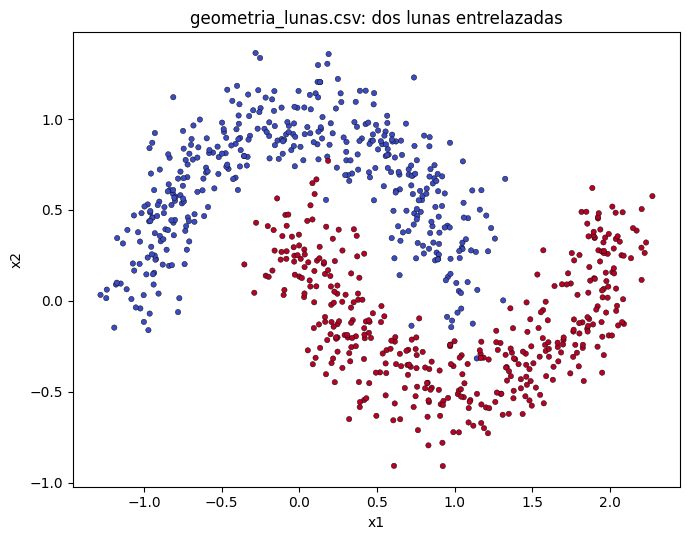

In [1]:
import os, sys, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "clientes_segmentacion_compleja.csv": "...",
    "diagnostico_celular.csv": "H4sIAChomWoC/219244tO27k+wD+k0JBoqjb1xgNuzHwg91Guz2Yzx8yIqi1tjEPveuc0zsrMyWKDAaDzL//5V//7W///O9/jT9//vHX//uP//77X/Bvf/n5z7/+/d/+/a//+Hv9v3/5+1/r//qv//7L//m3f/3Lv+pf/+Vv//6ff/mXP/7Df/zLH3/jP//7P/7xt//6Z/73+Af8xv/6if/rf//H3/7rH//2L3/7p//V9++9P739jvPTzX7jz9b6b/tpv70fjx+294ofI/5z/kff8eOf/pe137l/4uodfw77vfnnwnXt+M4L2z4LP8+6+NfWd17a72/8B+u/NuOi+D/ixm3wlu3mvfq8eUW/+D3d9sV1/dftx/Coe//O8zPO+uVDxa+KJz0jLzPvuKxN05NaPJ3/Do/bzbig2926XRv5Y9jB7fBn84G72a/H883f/XMs39Xjnp2Pg7+38aD453ba4SMevNT9jV/V8z1jNb1xVa6vwVfE2trGmjguG7+xqvGgZ/zceNyfGffiXzv4sXziV4yVy9PmPVPXtVzIYz8nFuRnxi0PHxG3usPyx5mXV8/3ZuvH/Lf5zxm/N19t1u3y99vALhh/SztTKxLbG+s/YoHjtSwWZsc68v2t4cHW4lYPu/w5jJfGMp60lpO2NmJd9ulals1FvYZ/u9P5i/IXwlZioeNZD6wsbtxt1IWwTp/5BHH/iRfoR/eLFYq/eSfuF4968oFhnLTj1nTDgTeYY72tGD9xEFb/ufmgscO/WMw+Ohbl5r9ZN228cSf8Nx7cdv55V/6KNQ/3osMow6TxgGvwLNTt/Hed3PkeO++/8UrrxK/Ck51FEzFegOvDpufVZsQlceHKE3vCMvetG24siGHvN380O1rO0/Pt+uforbLPM7gwsMw45zQav0frEq+Wp2ilrYUBzbWwMLER/KsnNlFGgD302OOfTis9OEn958zfOAXTms7fnjRX/P25sKaj47L7O8NA01hjUVqe3rBHmmkzGonTaOxOWJ+18FQduz/wrLZgqPNnN/+lT9jcvQF/0fbmC0wYW5ykvtJq8r5jxznsHhfq9NJHaFnjGnq2YdqNsL+4Pr1oz5e7ceHiQaeHmvQXxr2VJwyPErdasOt0nrfTSusg2uYPLGyH5dLWTt4sjnMcQO8/y51b33B64uLz8Yrt7DPknBa8TLqotIFYnPtej8sD/9KdNrpH12EKS5sRCLCa/rNxEvOvHyzGwmL0degu9ux6uYwQM2w23m7m280JDxqm5nzLyfU/MIO273wPijumIfDst3NkMYtveGDko2NhzF0BIiJWXL0zPsQ59fC93AQ63dnxb9Z55PsxPSj9Gpx2hsBzr84838zpD50+39rQWYoViZgX7xIWnBGwL6vlpJPZfL7F99zzjs/ZTW+Yb5ah6LS0NgQfPCccdhgpw+ieZWThH3LfL4wsTtO68hULtxsD7zcc77eanKHnjsd14UnSpYVvGuVDjykmwWC4nC1uX2c+XjXWM8LugUecsUr0e5ebPTYjks2loxi/sOOeEQHSaGLX03MseaeIQti6WH24mxbBBv/dzr26qcMjZlCLW//E02httHtz0hDwABGb3mVcnNi+WN8T/kkveTqfbTXeMf0LvIXMu2WUyLMbfqLHNo74kzGJnpDmEluD3ZgIcdj+xsiURpoxIvakTlPcE24GcCS2mJFmdT2p4QXjz/Ck4UCmz9p9+gpsY52Stvqs7chY2POO4UdjU+bo2v8tyMMrjjHih7exOlAzDS78oWU0jEdaBbhoofA3BbhawytGVAnDD7OLUzU7IUr/pa8XDnFsQjwg9jD+Qzxhr0fN26581NjhOcofTiKUoSVejG4uZJLOwtNGI+zGYXDXSdTe3UaXv6Zc/w5fxRvGP4RTG7n7Nyx1CV8cnJ64xaKdOdxTQpP0FXAa4WRjVQOTeB4Rt13vOBiXLm28jnGAjKl7LnjvePjYyPDzMyzn8GZn0uS4EQHBeOnW8YhlhKeKQLYRGH1srE/sHc7ye87YEzx/nGq+aVxkdHI9sXDiG4Hn7nT7uHffmza15MMR98PRRciIRd9wdFhRBs9Nm02b4ckeo5zq5P3ieIx8V29XZj4Zh6cTKI5Gw7VEyJ0esuelGQfCFyAOmOwOdwn0sQnAGTruLVSUxgZPl+5jBppaQqiDFxDuEYwl8hjlsAC/w1jKYdGxBlBb9FcA1K21RQOKI7dgshkc0///BpiZSBbMConJhOKX0egatyg88+WeIB2Ip45jsDyfd/Rez+u6PXezIadqCZVw03S1sY15QjxPi1kXhHctCf0c/gjjn1fuNV06cFzAzXAFkSEQOTQEb2vtfIBOmDIja6LpsJhw4oHf0q0m+lOwB05R9EaKQbfcuZUGnDrSFeTK3h+/V1ZHRGRwsl24eJ09aidxXWxsYpWftQpO0zwJM2UHYYx2+ZxOPBVhdOVfjge9whyuoEibs67jAbAIc43NT+fsPziNIyAO34xAPA5WowPYAAVhrYNwM+8dPnIEPj1pBTbb7/xGRT3vOPBnJIl7amHS2Fe6n0hpwjonEOcHUIfZ0AbG4smyTIt5ki9CVj6wZa7RicmxEE1Ilz+O8FGnXz6JHDzdjx7VK/IA64VZ8NZn0eztxCp1QB3LmJUnOm3o51otK9MwXq2zsa9XTkT8fjM79VwfrmkECkZIPp7O1myKkIY3W3m3HZYXNrNlbVe7to4pT9TJMj3nyuCaCXTmb3mzk1QDL2WWcJzO5+6lrGO8RCWdYq5teOUMBQUg7PavIBkmyp9zLm1HOo+F3CjDczIhFSXhbqz7YrD02hTQC50Wnh4AwTVyUl5mCJPDgePCYHDZahXr4v/Nm2YSHosTy6Z86tJeIhWmzzpc1wiZUybuE05jp0cOtx1ok5baldQOIh6ft8vEhyJWJkYz73xgsl+Z2KHd8PdoTQOZ53WJ42A38esC06YjP/sBcmRUCysUQQP2enxW9p4IOQ+W5T/3TOK5NJ1Bilty6dX9GU7Lp4xfGTAlwJnHuirVZKDYHbcL560gGbFae+hY1DTwTOcS6czCugI3jDxDnnHfSuAdSVVcf+Fdlx+GjjgF3I/rwv9Mb++onLrxUF2kVe2DruTP8hJ6EJmukUPLAwLocfJ8xAb4WvJVDN55a+EILFf4LJ/y/wsbGWcgAmQY8pov4Bhf7wp0KrrL58SFeNgEAp6Bea0iRgj+ns8YMqbIrndl1TtjTibZLc/HtlohIo2xPvGgbT8Vkw2xMS47YDhmYkmivklOo/HnEPSxWPoCdWlqBHURsZQ/KglPYM/r9OQFO2LDVzqPM/CggSXbJPhs4mJoAnzt02fRhEz+R1FN8Ry1jVv50eA2Kqie4tM6yS3PvDO8pE9lEI3bF/fHvYyJtV0Xw7EPvFy4qtiFjHLXFXKErAZj1XOU4ZPHlhNIMI97Aq14hujv1GyLa/B+uZ+jTCfgQtw0jObC6JfbHzgnIkNXpsY8+bwUK/kDT7By4CxnkWrX+VfP7Io7ureTF41TnGnSyOCRPvLCVc7HVsXD8mjgf73WNElmyzWN/faMdIRSisCNzJ0Nvm/fm4t6NnY/1hT8n10hjkhPmCvfSqsYlpsViEuEfdNbLdAqkU6Lr7j0wEd0r12ScXGui+FKqiKQ6qpMYDTGHGa3fS8RTvx9S0xOxzE+iTnCTcVS5C5yWVw5L5eHKeRIaN/LcaSb8/Qc8cvSc4jeVFQ79Bhhw1yda3jUOL/GyJrcDPj+KTyfBD74fmyFm5gWQesOSNyRO1iazQjgKRfKJCfSo6nMnrc8RMdpajsDa/zrytezq8VpoyhZetTBwBc7+UAnOM50HcC6ftqvfPFg/iCYtOQm+ZKi/gAfkqIecd8rnHtwT0REFDV4VvY9soEJiizicQDVWIF4pF/7grmDFyzfPFRtHQL5nXecea/wUnEqbTQ55CmGnGkd/XPuR+HVyGFI5kXUmHk+Dg/y5UbEI3uR6bS+xPa452WBYgEFxi3FI2Spwb5yiGvMIeKRjpbnYEPCBi7ecp0yO164nKwArf5+k/hhQIkC2hSprqSe0Rz+w7T/11W32TiG+dKFOo9VpYgxZm0FDSV0AdlWlXzyZkkGVfJZUGAwAVhKtcfsDFfLCgpE6EuGlVAgaxa7yj5EYl/EbHisxTDAzArwL85U/LnFJHRH+DfS8nE8WHfoVpwsnvMCPaRTbWJyVW5gQeQcZypZJj4yqCaHcEFbhfHQL4anoOHsIRZXzIfVdQeMThh8smSZCJR/3OIeOrNxepIGr96/vHhsbviqNJ6tyBHZpQxuKd/V0rZTcK6l17nMV5K0HkcbaYqmjTZ6jZ5uLtuPf+BrRt4Yt1lbkY448DCR6ENhZLgIBORh2MPRcMdbBAIvnPDMNl1eswBkz4JkuvL0j4Gs8lB+crnA1kr+DqGHnWPCDs7okdRs4pTAMSo6EOWYCQMsFf52UbqAclkkaWk3sV+6Y2M+r6SBR3Ku/s4UAuMdINfbT5rb/jrE7+dWLj/veFgXOTK2g/nKw7o6+FvFRiaeC4Qic1YgufjXA1r4k3sIis1dLJTI0t2KDdpdrqPosiFsRSi+2tV5lL2uyllGOqswgDjIgc/GvSKgVBJbSnPGbEqTdwGWC1OPgxohJ0xx7UN41cUeNZrCEG1n9ah5Vkbd8mccVUk6I5vOhy+ua3irpXCFKk6mV7EX8cvCOASQClHRaz2wshD+mT+2iWz1FSlZ/iFtlXh+f4jTtyw7E+V4xpXLUnmVCqJ+1oetRqbTFRtvrmf8rUgfE1XHfyEqXqpqycQDggnnnIpxGyRrvt/JQBkw/LfC4FAEFzUyRXTVXmSSkTnETH62J21pWtOpFFs0GymWDK+8DBxJnPu4LDyhVxrYmP+xfkQYsb1XRnaB/hOoAlyvo3LHoZ/Q/qfR0nCWFcJFchQI8iIvT2csIEeOTFyXqxQxh8k1xkJ2kAax5eF05tGBIhUSRjq2CBWypRHNi39uQContyNWbXYRKzq1e8q6ZXW2mMkdVAnyysCMKCi1IY7Eaday7sFntk7AkVYKyDmAc+O+oxWqIrNGDYUXd3Rm5Q2o/aZT3C1xwDji9C8Jitj9Lsh4GDn2WYVyp24Z6zIS5R5dOkhrHr9y/zSkkUkgrdVwhsMUwwLiNT1LuqImVfFnFTmSDnrkMbooK1bIc2t6Uog335fFfpbUyQUf1YWmyyEnv3/hzlvWkc7h+oSBKSujK4/35Q33rpPVkFrFDTd+S2QxCpAqHU3zP7n5K/ohIV+ezAX0eH9GQAgu/6wEnrXHOBrM59bUqex5Kkkm7QQCXlqORgmIkrLw4Sq8jeLYOx0BElaUoeZWUF6XJsiCQOee3LVKhpOMxSktQBJX3YvT5cIiH5gVwFaRFsmNZ04WsTV+ta9KWrt9InPkrsx5j+FwGa3bUFyfqD6v8wRDQ+8oUxez1wpbXaQscfSyGvCzlD8kB8j9GFP7QPcab1opXbiAjFgLbmRMFVnupE+cW6dRfGlfygMWWN2D0nNWoM5RgIx/UAX/1COoILWXwK6jLJjHNANDgF1VvppAdaMEgTXeUhvxHcF2RZCL37nO1NkSRNl1MBajzyh5hWUNMf+8eba0If2pPkDj0R1f+rtRNbqMPTdzrIOUZa6p7KqpgmzFABAYDh8lr8lj1SnngcBiqD5j0jlM5rvjo5aAjTfw1rEhO5fgZ2zpHRo5p7ldmYoylnnqYC2kV30iN4+T5Vd0x2ag9PFnUI7zl+fZEyRNcB5WtaArmOmUV7xLIkVsSMfjYVZu2mimBVkskxoP1FA6vvuStaSgChmFzAWKuC9RzUSRrSu+hhGtqld1naVMibJetXjHZVX+47M2CYha1hJN+05OJZ42XLglg6wa+9mM32OTGIs35o07oaOBUUniMYu0htLgLCKYr3hRUA4MxrLAPhLIhNuKR8xY4rl1PQtd7eOf7GDHjZGVwgmiXAj3OkB1OI613kFU0nLFIRQCOfcrAfTEORvMvrfSWKi2eph8Rr5zJCgQQpqos1v+ggBV+Qt6013Jx1EhCE9V/OOQIoCCpdjPjDVhCAk/lUqzJrxqN/QCzbxVVWew6JkO4FACWLVo1clPEcHKsOfp3+h6p0vfcCFu7YmsaBeKA+M0Ke3k6iALSCR5k0rKCGuVuDShHEk0xlTRflZsBjKn94gFVnjN3IZhUgXhQwjUM2CLZIFspoNKDqcS0F93xHoaC2Zd3mctyVGYfWBjDyrSs20a/dmuWk4rpYZ9V8xuJhwsgAd8SJ3eYSbQtB02+IxfNGIGq4WCB5BPqjiZiA0eZVLBjb7VsUZkSEAGJ5/UMvEMZ/Jdf5RWVFTi0fno5EZW8nnJqIyAgTrP+7pC1VJRR/XLscsbMyczFNlSJHe0f/ZdKFduP21J2NFQtTgFjpI5FmQVCI+1I4HFtArMg2ozPB4X8qUszntl81NJLjVvvdP0UJQgviZFgo2P65cXD3yIPVXvkM7q1uIY4s1M9Wcmyl4ajTvPVzadCVb9bFsYcALMZaADlXBnL7abWrcS7zKeb/DRBB1wWGA7cz37EqQvh8WC/NAba/tRVUulTETjng88pXSVUqGTmosjdFTOLGzklL2ktcUB9Yet7xI6lWxUKcux8lVJcaw88uGrYod2l4c8Z8tTHiFJWmrbqpSD7t554pell7M7S53HfMrEOG4KPfqdVQtulAMuRK0NzeL4Lj/tQWJWp2u+OkBH1JqosOYBflXkxqJ+KQGbCOFW5Epyzzgk8ZaR9W2oQuAJCaeWIPlhUB+dWUsWAmCsKZccDqx6X6n8fkRvTO1jsVb/QxF4obOJkJpesWld5TkIqvgzEl9GyKOUHvuZ6b99BA88TxQTDvK6jM6Ef5aMVdaUQQper4ReZ6JqyKVj2jpTmQbC7q5lXF69PR6IBUtdT3S9/GOq0GhdSMcvBcvSDlBL3yU/a2LkhKqJ3g5kb5ChZVJe5WNKNCozGyoIugmMJS2K0hHUnSPLAjRrZZBXIUdBC+oCJisUri7Ug3MXn+CBVZx6SyltIoPplauMn8HjhR1MHq6SB7q38ckg8pF3layQ7XYUZk6qAitlXS782BVQJXiZq2rl+ZiZjOf+XyjKxofoSiZSZCkrXbOXFAjFwJkS8DzVI29P6pH+eDadR4KAgFpTp4MZYGbKLSnZ/e5o81N4jnfc/8MCDJ0Y8WsPxEfTFXSOMl2/ooAm98dckgc1ReSyhtXNVBJrK8Nc6EmXKpGbP321QuQkWWIVE8zFe9otIlBkEjOj2AyVoKyXPBvl/bhdSoLmR/J+GLLUBRKHQ17yUw4yKS0O5Jp+X3RtVfO8UoWqVDJWYWWo+gdynTgYsw2xJYcFOukg6enWWaVhpqAs8WCu08+5f4SP8E9GuFytHSyVWfYCJMUCdeG4FGclxyksJYplsVQSZ8uKYItVG/ADkSKFj88el5LXcA+F6ePliTxjeb2cZM/7Ii1IwXsKenW8Kt3cEhjTPijxy5AMpfaF2sryl1R25dLyKzIH+KPxLqrmkjAY6uU5YOvDPiqJ5Ctf2mAXjR3AfhUfAHFI5r0oevS1yxmQupST7OycMB7peMsn1Mg6PciL4hEkKDhSQEdAk/LXCrkYdiZQVNp7mJ6JbTvi9aUQEFhyV8UMHQ/jglGGHVyrXOIIoBGA+FMVlNiXQg34nzDKucW1XjfVr4ZUabL1UVl9etsJHRuE+75Vb42EVwV9JXU6cL23opKg2u7gvePvjHO1JeTkO0tK4d6lvBagB94xANEDgDYrxh6VLRbrNJn+7Ie36diz4pmbIZ3P1DFRN8lUl46rCiYuCXuZUQFOZKflbxEC4skZpF1SutEKLDMCjfR4cZSmCw5u6ooCyFuVlJfWpirnBwx2bM8BwfzhzbfE8/zBUzZeXTj1iJPETOKm4SLZbon7pfILMyWSWE+tlXjLcyNSrRWJmYotXUKGrUTLq757ySkbNGymOATwOqRIKeEdpTq2aYKjMA9oc4deN36lV3p1h6uCJFnYKi+5bpXbgNCPPUbwo4BjK5nfTycEW7BwOlDEkJNscTiOnGs7X7p2U82s+tAu5D03nXJSl5mBLGGsJh0anbOW9Mxbh+oC8zbA87CC1aoj5a7XMQg1pHTwXt1kcebtsGkRiktrtY8UP1DO1vdRqPXqgDGB7I7AsTvL0JKRGat75i7trumyxSwS/RqpZCnRC/zbYGI1uixvV6k0sQ63nb1r7kJ0fDgWzLqUumewcYL8SoadVR2ZVl0zX4FudjH2Y9Te4dDnVeBy4v+RCG2pb8JUKpXVnFHNSwbJffayZE4YULfaAa/osj2+FTd7tnrDBY3uQLdpFj2nGHaue5ZHiaqsyrT+GqZwz/QDkEBdO08aqISQIfwKbkXAqrgRTzM6a8kZj7u/6AjhYW4393RJEuDlpSC2uck854Eaha8i9zzfiEytLba86knzKjsP79/Xpythq2WtOjVcbX5WGNsk0TCQJBk4yk9dtXUttpcwYH3cTVMrafxndAeNZzwMpiYpk5fzf4E8vc7Ks3+Tc1pDqoB4GaVIZMmSECLu+EAWFNszUiHHHzK7ZD8JzxY93LClUsvEpVZFjxQKObyI3/5nCxVbm0wgoDGvD0fF6LhQo80zLX3PlabIF9+zInn3RyWk3gbCt6QS4m2vMoJTRDtjVhjhlWD8015GhXhC899MmCQrNFNBSdJ5UyHzI0kfiDkLePBCOqWCUhW9uP3xmDShbL+oKv/p1VFsqC/1YkApzMlsWdU3JhbzeCkv55UuMUBkBMRUegyxUQw5rQonPKEBsr7lJSihHlRs56kgwrw3W1z4K9QoOnavHC+VEAvOFQKaEol0kQNk3K5JCrce9YmezfhL2/Nhsw9H8bEk9wyw5jIiJWqJPRLuHPBYULYX+JCsmBniooO4vqpCaK76cgdzflrpSyn453r2W2BSzVSEEGgM94x5s6iaeNAjquYrUx8iaA2McFYiN6Spfm6hVuI4N65sY/NnSyDgn24h6uAiVU8I8Rjl1VR6k7MTbEld9QfugKM9MN/ZVVaKTEeAU8fbBJSUqndJ6CKgRtRKaPYaKbgsotuv8ZbzU8gc4MDiZmFuARTS2tWKxY2chAXZ+nfVw1FNgw5bj3/NawZUzdXFRcCjUKnItFpV/C8eFhllXndkOxEN7KvRsanu56fXplxo/htkFD1lFKMqUgLbQr6qMownv6X+KkLERoNjsidbSSyPIXnX8JsiFqyy2CSxUbJP8U3gs2u//VOZ/RhEV/ntaQUHgUvCkIMq1UeAS/4zfLKpz2iphq+GvEaZUAb7CAvxouPR/LOrMU6XmiDzWPfTIJcHDBxaizftpaZYInhJENtHilcKDuOVO3FaYufCFiyXJjLjGjljC2D3R4c5kkNd0Pw8Haaqy2vfklTzylKogCnqQMt2kZB0qf6kFnBqFKUEWfYZiZDI9/4ctLj47rIgJ93TRIIrgW+3MHojb7ceMemlMjzsqDkEiKM6ZZ7UGGndQnEiX485AZc0LEFGI8e863Cxv6HjVIZ7Tz1kV/Qa6nOkC1AppE+dkURLBro+/Wu8Yd+lh9AJXmVuYu1S7v6yrYmGXE/kNUedrll6COmEIsnnP0DKz64q1GAD+aDXwVVG30WAd/m8sY6u9P3AE1QYHBpwMW9ArLS0t4tbknCCNdJwi0+NA9qP3WqbeuxKPlQ9py4nMkUisFhAe/YOX9KhrM+FKmXl4Q2rRbJPKc+7l652QZMTT3vRMBfBTbLj1c/naCQckVLhqPzDtgqoQY+xmFvudl///8Vsm142AdFhupWN6RXZoCmq8SqNLnZblNG5bVf/oQoW02HJonJFFCWW2P+joOaEibN6uk5VYmYRqUMEldpCE0GOj6i/I2imqH+iAqR2PvXIWZdalf46e0P6H22vCYvZ/dpsv0kgosb3Y4Kb+nqyEdDoD3LQxUar3PzyXtLwxA9Rpa3cNJV5DfQL6oaiGKe0+FOnRPra9XpBjW1kuf2Z+w8r18Uu/a5YrYRlZGmIrqRTtJ6GgN6lCK3Fv5CimFIuCqhuW1+tZCOT1DCeYzCe891+qj0ZknHoflT05wKPCYdZ9AIXkmMZbLJ0NV/fGrxBBIsNJsTn65eWInuK8RPrjHZC8bcgqgf0ChMI6H7pVLYGhwypFazKf85JEMnfX/TCri4u7EpHNVk3aGq0CNMYZXIN23ghr8+SnAuN7HLlqjXFcWZFINXn1YUIQR6K8i0FLqfQAQv3GpgQqYvK+sxO8jr2dXG+w4xdWSU9JZfJaCDRw0aFnF2PQ8x46kizLWxU0keGWQS5WtA2iBXCGPBo4dMOujtnr9aluTVvSKpyEmt2v+hmEnAbKHMIOUkjn0Xfq4PIFU4lY4k6DTpSVCszRR2PLtRuuMsxxxEdkkmo94mqA7TObRRmUrQkUlpw32j0Of+Cdz5TLUzgOFKMAhIgjKIf9SFwP9jS3ilcUz8lVwncn42H3L3IWGmt75pPXQdmTPzfKc3CQI9fyp5u6VAYwjpbGboGIakU0BCIWA0Cuh3QpH1UGZtNN+HN6RX6Jo4xqEjTcyQ9DvX8fsCCxkcjQlMHiOeqzaOQnHOIHHKpV9HZqltJJq0H8Nf/nGQiZZMLfUl2msoyXlDfzrfmzewWtMhLAcJTJpEjNGpSj1pBNC9nDv4McFLJ4gKZn2o5tOjEDr5WZkK0ailVTbKNL6XMBMs589iUUqbaJozP7DLbYUWP2JIEDXhiWC8e/9hXpSQi9akxIftLFpqBJBxJ+OgwbqGgoWkYCtRNxBz9Af3X5k2xKVncXQ9SaPQNPYgXUTLt4T3QQA3kcViYt0L8TQj6SCA+RT4Nq025szZlA/DZkvPSCI72yfgIMV9nIdlVtBenkKhIq0l0J3HeO+boGnoVzOygQy9CzqQSr6dOJMPUq0A3nFYimtQmaGfkUj2xaY4ZaVVlu7wO3VpDEfv1TqT4ZWJZk2IozUR1T6o1PKCERDOzbKeTathpruboDFD5QCqrprKXKpCYeqckHjG6oQQZ5u9nluZOHabSoZCxuP0Lj6KMnPKTCzavfbFyElrcJZFOVVnHFw2IruZ5K22TVHJqCFZXWdkk80+kBBFbdnlzctAjDaTO/oxEkbZ8HIF2Z3thzqZBNcC29rEp3NbELZmOtyqzTgooczZceqKk80SGle5durmuwzL9TXBhH9xGhdZRxRaKlVZCHV+V2ZgrLTYlqIn2oWn0x6+RL0gw+Ecu3ks7u1grSeTf8po4y5WLn/Ut1ZvqifIzaviLS6+bs3gilkyrWvQo+nBpgoYWiSyHNU0qyu0ZGK0Q+/HKtJ9Rc+kBNZvjvBZliNkGLoR8opwleyA6ZSyR5KrgMguysT/FErONjmZaGhzn8AQuEPwd6tpJDlQMLWSFCPWgH2cBqCf6nxr9UYMZ1EkHQauxY4TD1I59zwzonPVXRZPZCgSxIIE9yfzxeDV9bhJ5zsBwevXKlztQ0xdYoGxR6TWOR0NUliYrVOXU1qy3HCiAp9QU1dNxqu4leQ83RgMVMYIK+7HQL5ImMTijcLwOLOYk9NJ9mnrs/ZWFkUalHwFBO3flbNIxL1Ugbc5PA5CajbYu7agk7teexGqEtA9raZJLxlxxKluyvZ2P9DNG1U44Fq9T728idV6/YIqbD1zQBIW4xFdtSYtcmUwvd9DfFKin2j7o+pinvSlHUrMpqa3WeH/0Y6MAH4Fv/IzVFUmAtqxrmAZZ/jVWKcylMAM/En91SLhP+cBLvrYGnRUKbl4l2pZJSunSE5pXA7ZQgdeowfI9DYN4No7WzlkVKoKFsc3PyMFHJNp9apZxJaM6MCRfJtDkUhTsby2cnaLm2dYWdzyT04pk5keB+VQjtuYbvoEzGeV4stQXtVzBpORoknpxkGoOPOpfDgQMwT6cVFE1iNdfJDmDLrVq4RzIgtAeGTaQ83HKOW8K1F5x3zQtIRVShUSAfn85eSoTjLrrqHGf/oWlbavHiWVeqnehgu59V+GcaRRHup25XjvYw4ZQ4y9AmQ84vPTlYa7VvS169bV/D69JaVA52iP0NPCTWtoPkTI1beC+qYrulVvCY6jgzqLr7cQ8+UDsGEgiBRofb8VvLg7+5GjE099vIfOCYb2w0raRBdtnwFAmB4ICSoqHlUKssYv6QN8zIfJWGUBqglFTO9RlYrMcx+wqBECmPafaNincr6qpekvmeO0sR2DwADZlV8PQDUVmXHVGq3T68lFmIQeneGR3ieaT7O3qZqXXkWAiS5m+Pg2KHIwGeVhy3Kon0gEsqWhNNGtfo5RBF1EuWVZDFVwJDBksI9E9NMi3Swvd2fCb12a3V/aY2csI1Hxd5YNiNm5hrLuEWVL8EsjDZhGj9Pj7qHCpsSP9vC68CysN95zVjgPlvbIfSSyOtJ5q5LRXvOJE1YvGz7i1rzIDuQ6fWw2KKtm3WVQ+R93Fpm+UpceuVhOxGHSprhZLu6PYF8L0gxaKZI3aG6VMCzhTmtbS/JRnPRzoCC41pfRdnN+epZkg7by6IldVwTEN29htlJXT2M2uepBma1KDqWkOkTM+UgzU1sUB8/41ymd9S/bBcOq4zDLbsdTevMGuvs7o844GGRHT4bT+FbWW7D3unFm3yNstYZE6fxW0XK2jiQiYdE+c6Ti6DyhdzS0cf7Dks9v5muuJYTWXtMb91JHmR6wagWBWabtUnzmwGAOIc0JyGH6vdl4eLWctM0v3Si7G/dTdc5rTzsMysn1YY0ivpsAd9YlMdfP3rckj2UObGDZfNGLfLnZb3bzK9U0jwdC9xmfl9LkD35w1IWl4KbSiqXcVr0iPMA/J8JGnq4HSklb0jWQohkAVNvNXmuHwAIfoM2x7nFYSMYEx8gMBIPmGvUYdI2HSuLtMnR1Kfk7tXt8y3MmxkA1NHQIDgMsXLQeIeZqmzlbzTldQiuoy1tVVL93Q/ob3/UNHqyRgi/Bxv99Q8KYNHDTlfoSQasZSOCg9neee9if1uFnCXhyWcm5pBGU+EtEewft+VyFeiVNP9nFFdjBaVa40dygSdFP71pahzzcNCLWKe6rjcIyn+Fxf8r2lSWJWoxIbRe55IYbzjXlLYCJ3pdS9Clj9IxTJihvU1GEHzt5sDS+cfxRXUJxlwfSrqLwTux5Ok2y91BP05C5rFU8ZhvXmQeFATw6g6D/VIFPzzozqFjDqHDVb1o7cZ6GM7dnRvf8YQi0XW7HX9quYdnDVGR6U/lbvIQfHdOdMD/1bDTw/ICIwlkFDbHuxRDwlkbRp0no1k/mnlytTdbJvOd2pXNY18ei7aqY1LrGslrx6bMiFcmzeWzMhvx5YUWT5qoFgnOs1OSwzZ0Le13oqqUgNrVIZu9VcT7RHY8QWRsKtXr0V4tLnqfkaksNc9y/JTrq5QFtw7TUQjPMKm7TmVbDCJHvdk1qqlfecWSh7SmN9b+BxoSVwm9UJchH2DMKmgdHJPJPFZHTx6yqaLZWUIaU0DDHusKTU8SmJoffRyG5VOtioTQlEzaJUOlF90ufwSC+12HfBguT/vxJg0loLQrfhmkd5NCTHS6R+pcDovaqPbajs2dELel+to6YCVquzundL1ZThEla3N1TcXj0dGs0kB+9CqKa8ciMu87Yomd3zyUXIizP3EYdHTo/WjmOJXvnDQTvVpKZ1EjhcT/dDK5goyAyv+YezIonmwKnIpWW2a6Xh6xrU1kGe9WRTJY2WipZT/tUq0UmedDB1nJizAWJqKEh2io7PrPckeMRsaw4FjNTQRWIbjkCiwc5+80SznRNFSgo63lzJZDJQC9wboFsVjqGeGjXXKcreN25xjoqV0HrkxH37mut0hdaXTufyOz89K5k/TWT5BrWP1MynJphzPdf6YwQqM16U9Q9mTM9Z/etSwEVglLuSEtRWxZEFqGXQeiQh2mvy/tC4KwnFdhed8RibbMqYaOdI/UFKPa5UCJJ6tJqWUbOQz2cACjBeTV6uIQ0KVVNEyKs77FUBnqJsxPcsB92aSXyPeo6E0qfGbmQ3guqAJxXPKX2Fn7yjBsyeKw3eFz+wnAp5Y5Meqrs9x4XnqN+yoKP23rx8cDQQWSYW19CxAnkHRoSuaj+ur3OY5p5sveP3tMYD5SgIEe+V7qlIOU/py5YEP/vPSeoG9Y2dj/pme30NpkRtQrPn7aXr0yLZQxSu0sv0NIyqel5K1101h+4auFKz29er8M+vkSTtyb1UQFyg7HruYxZo38yMGpsiDqS+LZJTpm7NeEm+Jh8AmuxbpcdLubIxVTRGT7aZclVN0s9MDA7Q6PlyOWxE1bimOauLHM1LB53LKFcmouxy5kv+W60YpCcDfT26Lwuj0MIhGuSA+vs9Z15p89p/dHdjgAEZxuxZy563WtMmBz5dnKRmN5gVH5KhEkTRhuF6jenYq76yc//klpB9ZEQnjuwBQf+YBaAKck76oZ+br7x1IEDYOMWHQ4nFg7h4W00sGBoNtyubwKeZ8pMkmLiwuioMAcoVz4+GQ0tAN8tvXEHeFBpvICwp7ayyXwUqE/R9Ew8c5fzJPqfUwpXUXa2dRWWzRJ55wS1dB6DS5LyORLA1Ho49s4cf+VGedvutLL9zZPMoFmS+JEY88ZFw4Ha5LNuf17x5InNOHztW5OTkWEsIIFdir9XJMT63rfe1iGofYpDrNbFNVejsspFYFEDA35i/J9usr63oszuuz+5Unp51Kg5Pa0nGbX8fJyEgv6KyutoQXsMadE8c65BHY2sm6Z2EKpQ4hBeXu/L1NcsYpymRRxbmSzC8NPRIIGf2+urDLfmAg1vKhiUD+OjrqS8pzXHKL8n01kZScAAibIOITfXA/JpfXyMzXZ1Eoz9Sat2fmraXk95qpNB2NbloZsVYqmiMVkP3OLLf0dDXOe1Zze9XlB89v7JCSSg72hXTm7PPJoBdCYbL2pamL3r1+5Zc9KjFH93oB+Mh2v6jsGXiJfns+w85LLyBhoI8+ZvUza6OwKwclgiy6rgdw3Ay+YHZ5pQwaV00wdCk9j0iXdZnKqmh/zR8ZKb7p6K5tA1HDWzrqLvvzrK9NSU01tcJTk18lmC8PsPAF52f8o1vzd9L3S8nzCoUlChNubpozVJFI3xkKsDxopk9r+pzqHY8zcARg89p0bky/PodPzKFD5tVHnskUWawE6Ni9RUm0n1UO6QLeW2dR73zy78/5bD6a0M6JunvRQv0vPW9N417ZbFA2HDtWVM0J79vYiXY26s0NucLAEwt1TDSbtRtawB3jfoqtdRQcYsBWnr+1vR5CoMQiPMPEJmdttMXNtBMY81pc/i+DSM61bNxcnL2VQoWNNCWXwuyap1XJtNGMcWGsNXQlJEkxqxm/bs+Yw3jhG4Ri2t91RowXHZjaYYOs3QNcs6ZZcmPrBosxgALSjtFJDUF062yV4EVFcdqHAHYts8X7cItD2WS+mgDyz5NFUD7o6lmQbSUhf/3jcZKXNb6Q41qaxQTcVDyw5TwtXAYa8I0n5DfYwqsqxxifgrGSggPhgvPWbqjmoIvzyzn96bKTNQ1Fwfw3/cFvWwjM5EKynVNI7/kcmZ16e/6uk19p+iqH7iU0FvjNB2uqMZaU4m/jb36jyNWo5yKKarLW9JLb84TB5NkY1ZGy/dxm6U2UAobluY5zpplcW7NXRmNLQr+R8MSEZMTNV9lLdS/vkwgfdWVseoLVdpKP6bCXKuyz0Zk5pcsO647H1FoLy70fIab41BBJJrAZaINyGbNwJEI1ZSxqDLmmjCOzzehchoJOPQ1/tJzfg+LH5n8/pzoazfKiJN2PWqyU8nKndOkUogqEftc67XFoNC4jsBVQh1RmKJqpT48NU9CksdUtydOBj8c+euX3Fakm7AnqTNzYqT8ohFGr/WUzc8B2fz4nj+0tCbUTmf+8NFS8FtK2U/HbyH0ry8hvsl0NQDrzXob+BaibUxQTbFAiT40wnyNp+w9akJ9yBMzPrIJB2XRecVdmBrbtiZn1piuYi4amo0cXzVIDFCfKetfX6jhGEJisq9BlhkYUUs9ia1K17CLQZb3VuXQH2uB+M/aguUIzPX95bc8QXKm9MXzlRZODd0S0p2VPaoQZuJzlKN1SikMHLtB8fGmCn0GZqyvTz7MypRnfTIO7p8JVnL8a5bi7Ow/vxm1qnZX95xoeYVin+G/FW6gZIh1bRMYGJ/RFZgPFldf9IHlSPvzJTmUIsYldeqveLbAQDoy1sHxA8z+mUzPqfptTU6gzijFAmDZEh1v8OC7KFqlrH72H3lnrMcFexT3iridFrsl3TqrxnTJLWsjxmOs+HVRRxkrDo1XfnSvSEQNitdU0fLCrnGbF18KC1PMKlb1POxXhi/hYpYIpMh18c/52VUIcpUz7urldY0gU6Jr3wwZuu8OPviV8FbvqIlS+rCQ1bhN2/Mj5sSo34PPb8xT1Cy/K1HVvlEdg4U1hwbfGCw8vxW0x6MCSVhs1z2lGnOvMT0DevDs+8PM3uxGUTwa/j0cSLA1FZn3WyuNsc0LH9Qd1qoyvTUicCmcyun4UIk5myvIJicZlPzeLPigfFdTvocaA+6ngZ1o1TC19dwn/Xp50tIE1BpgknMU61LWUVF6C58bqF2VDB/i1+3PfiaU3JSVSbpe0si56q7KV039x/PV3EDM+NA4olRTiF/bGl9QBUl18Xl9ESNLloaGi4nvd3w+NaNxS6qFDwmPup03F+Ck+V20+sxPC8Pp1Qyuj+P2NxKxLCHPM4oQC43zw3pN6pEcWBWmq7bcGjFcjUlZGnJOUShRRI1dahLzqvjfe9cs9Wz9Mk7euuiKeX2Vel7XiJe3IyB0DO1zF9X+NbegABvKVHSTcmns8SrhaBlNER96YLI1soZ29s/Y7y5X4jUSxmGfYJEv+lhWe18ZsftV36vqkI9Xr81xe+lUJRusgcbb9ckODQj8Un3leCcUAjoGJaVmXZzV+VJvqXDhVqM9LqbKNX44p2W42t8f8BRVFSkngwAHs3DUmlFp6Pg0le+aYifyiPNc2GMxTt0uDwW/ZT7yJZOLeB+Y+5qeqQ9j7VvSXShFGz9JnaO2CsS5IIap6lXS1FafaF9YyAGRcar2Vo3Zwv0Yx0fxSLgIod7w3W2H8KbXJ8Ur5rraxGv1/x9mzKlSdn8AAA==",
    "geometria_lunas.csv": "...",
    "rendimiento_industrial_no_lineal.csv": "...",
    "sensores_maquinaria.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("06 - Maquinas de Soporte Vectorial y Redes Neuronales", "data", filename),
        os.path.join("Data Mining", "06 - Maquinas de Soporte Vectorial y Redes Neuronales", "data", filename),
        os.path.join("..", "06 - Maquinas de Soporte Vectorial y Redes Neuronales", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/06%20-%20Maquinas%20de%20Soporte%20Vectorial%20y%20Redes%20Neuronales/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=2) as resp, open(target, "wb") as out_f:
            out_f.write(resp.read())
        return target
    except Exception:
        pass
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df_moons = pd.read_csv(load_dataset("geometria_lunas.csv"))

print("Forma del dataset:", df_moons.shape)
print("\nValores nulos por columna:")
print(df_moons.isnull().sum())
print("\nEstadisticas descriptivas:")
print(df_moons.describe())
print("\nDistribucion de la variable objetivo 'clase':")
print(df_moons["clase"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(df_moons["x1"], df_moons["x2"], c=df_moons["clase"], cmap="coolwarm",
           s=15, edgecolors="k", linewidths=0.3)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("geometria_lunas.csv: dos lunas entrelazadas")
plt.tight_layout()
plt.show()

**Lectura:** el dataset está perfectamente balanceado (400 observaciones de cada clase) y sin valores nulos. El gráfico de dispersión hace evidente la dificultad: las dos clases forman dos arcos entrelazados, cada uno curvándose alrededor del otro. Es visualmente obvio que **ninguna línea recta** puede separar limpiamente ambos arcos — cualquier línea que se trace dejará una porción sustancial de cada clase del lado equivocado. La Sección 2 lo confirma de forma cuantitativa.

---
## 2. El Kernel Lineal Frente a las Lunas 📉

Se entrena un `SVC(kernel="linear")` sobre los datos escalados, exactamente como en el Cuaderno 00, para medir qué tan lejos llega el mejor hiperplano posible sobre esta geometría.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

X = df_moons[["x1", "x2"]].values
y = df_moons["clase"].values.astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

svc_lineal = SVC(kernel="linear", C=1.0)
svc_lineal.fit(X_tr_s, y_tr)

print(f"SVM lineal sobre las lunas")
print(f"  Exactitud en entrenamiento: {svc_lineal.score(X_tr_s, y_tr):.4f}")
print(f"  Exactitud en prueba: {svc_lineal.score(X_te_s, y_te):.4f}")

SVM lineal sobre las lunas
  Exactitud en entrenamiento: 0.8643
  Exactitud en prueba: 0.9000


**Lectura:** el resultado (**86.43%** de exactitud en entrenamiento, **90.00%** en prueba) no es catastrófico en términos absolutos — la mitad "superior" e "inferior" del plano sí concentra, en su mayoría, una clase distinta, así que una línea recta captura buena parte de la señal. Pero el número por sí solo esconde el problema real: los errores de un modelo lineal aquí **no son ruido aleatorio disperso**, sino que se concentran de forma sistemática en las puntas curvas de cada medialuna, precisamente donde la forma del dato se aleja más de una línea recta. La Sección 4 lo hace visible, y la Sección 5 (kernel RBF) muestra cuánto de esa exactitud perdida es realmente recuperable.

---
## 3. La Intuición del Truco del Kernel 🪄

Una forma de resolver el problema de la Sección 2 sería transformar los datos a un espacio de mayor dimensión, donde las dos lunas *sí* se separen con un hiperplano — por ejemplo, agregando variables como $x_1^2$, $x_2^2$ o $x_1 x_2$. El problema es que, para transformaciones suficientemente ricas, ese espacio expandido puede tener cientos o miles de dimensiones, y calcular explícitamente las coordenadas de cada punto ahí sería computacionalmente muy costoso.

El **truco del kernel** evita ese costo por completo. La formulación dual del problema de optimización de una SVM —tanto de margen duro como blando— depende de los datos **únicamente a través de productos punto** entre pares de puntos, $x_i^T x_j$, nunca de sus coordenadas individuales. Un **kernel** es una función $K(x_i, x_j)$ que calcula directamente el producto punto que *tendrían* esos dos puntos si hubiesen sido transformados a un espacio de mayor dimensión $\phi(\cdot)$ — es decir, $K(x_i, x_j) = \phi(x_i)^T\phi(x_j)$ — sin necesidad de calcular $\phi(x)$ explícitamente en ningún momento. El **Teorema de Mercer** garantiza, bajo condiciones técnicas razonables (que la matriz de valores del kernel sobre cualquier conjunto de puntos sea semidefinida positiva), que una función $K$ dada realmente corresponde a un producto punto válido en *algún* espacio de mayor dimensión, aunque ese espacio nunca se construya de forma explícita. En la práctica, esto significa que basta con **elegir una función kernel** apropiada para obtener, de forma indirecta pero exacta, todos los beneficios de trabajar en un espacio de mayor dimensión — sin pagar su costo computacional. Las Secciones 4 y 6 presentan los dos kernels no lineales más usados: RBF y polinomial.

---
## 4. El Kernel RBF (Gaussiano) 🌐

El kernel **RBF** (*Radial Basis Function*, también llamado gaussiano) es el kernel no lineal más usado en la práctica:

$$K(x, z) = \exp\left(-\gamma \, \|x - z\|^2\right)$$

Mide una especie de "similitud" entre dos puntos que decae suavemente con la distancia euclidiana entre ellos: si $x$ y $z$ son idénticos, $K(x,z)=1$; a medida que se alejan, $K(x,z) \to 0$. El hiperparámetro $\gamma > 0$ controla **qué tan rápido** decae esa similitud:

| Valor de $\gamma$ | Alcance de influencia de cada punto | Forma de la frontera | Riesgo |
|---|---|---|---|
| **$\gamma$ pequeño** | Amplio — un punto influye incluso sobre vecinos lejanos | Suave, casi lineal | Subajuste |
| **$\gamma$ grande** | Reducido — solo influye sobre vecinos muy cercanos | Muy irregular, se ciñe a cada punto | Sobreajuste |

Se entrena ahora un `SVC(kernel="rbf")` con el valor por defecto de scikit-learn (`gamma="scale"`, que normaliza $\gamma$ según la varianza de los datos) sobre el mismo conjunto de entrenamiento.

In [3]:
svc_rbf = SVC(kernel="rbf", C=1.0, gamma="scale")
svc_rbf.fit(X_tr_s, y_tr)

print(f"SVM con kernel RBF sobre las lunas (gamma='scale' -> gamma efectivo = {svc_rbf._gamma:.4f})")
print(f"  Exactitud en entrenamiento: {svc_rbf.score(X_tr_s, y_tr):.4f}")
print(f"  Exactitud en prueba: {svc_rbf.score(X_te_s, y_te):.4f}")
print(f"  Vectores de soporte por clase: {svc_rbf.n_support_}  (total: {svc_rbf.support_vectors_.shape[0]} de {len(y_tr)})")

SVM con kernel RBF sobre las lunas (gamma='scale' -> gamma efectivo = 0.5000)
  Exactitud en entrenamiento: 0.9839
  Exactitud en prueba: 0.9792
  Vectores de soporte por clase: [41 43]  (total: 84 de 560)


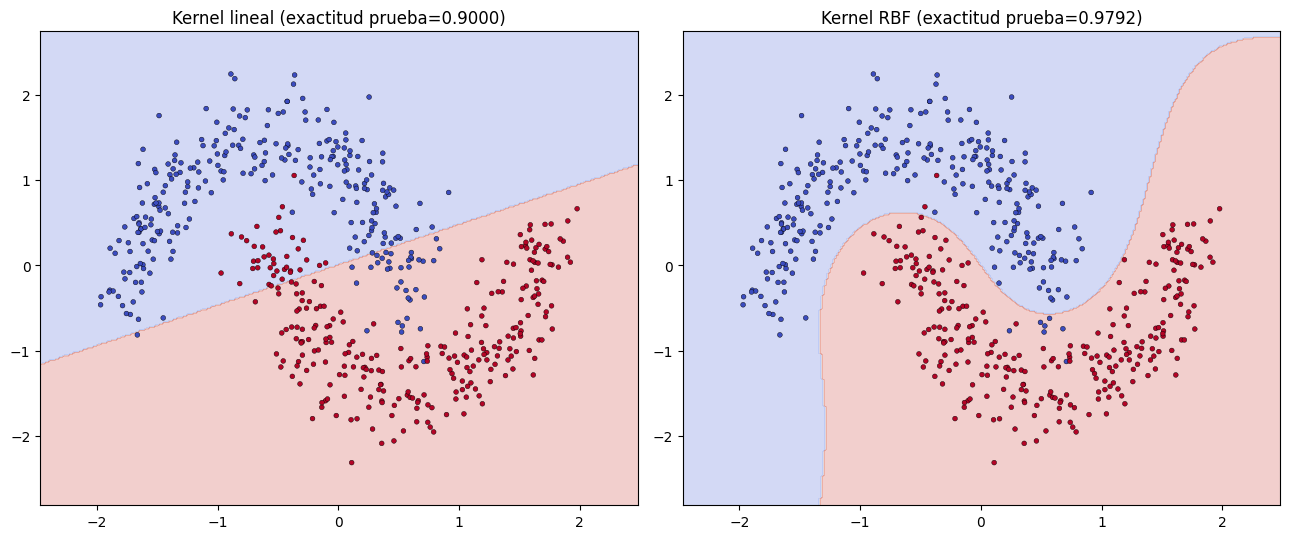

In [4]:
def graficar_frontera(ax, modelo, titulo):
    x_min, x_max = X_tr_s[:, 0].min() - 0.5, X_tr_s[:, 0].max() + 0.5
    y_min, y_max = X_tr_s[:, 1].min() - 0.5, X_tr_s[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_tr_s[:, 0], X_tr_s[:, 1], c=y_tr, cmap="coolwarm",
               s=12, edgecolors="k", linewidths=0.3)
    ax.set_title(titulo)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
graficar_frontera(axes[0], svc_lineal, f"Kernel lineal (exactitud prueba={svc_lineal.score(X_te_s, y_te):.4f})")
graficar_frontera(axes[1], svc_rbf, f"Kernel RBF (exactitud prueba={svc_rbf.score(X_te_s, y_te):.4f})")
plt.tight_layout()
plt.show()

**Lectura:** el contraste es contundente, tanto en números como visualmente. La exactitud de prueba sube de **90.00%** (lineal) a **97.92%** (RBF), y la exactitud de entrenamiento pasa de 86.43% a **98.39%**. El gráfico deja ver la razón: la frontera lineal es, literalmente, una línea recta que corta ambas medialunas por la mitad, mientras que la frontera RBF se curva con naturalidad para envolver cada arco, siguiendo su forma. El modelo RBF usó **84** vectores de soporte (41 y 43 por clase) de los 560 puntos de entrenamiento — un 15% —, todos concentrados, como es de esperar, en la zona de entrelazamiento entre ambas lunas, donde realmente hace falta curvatura para separar las clases.

---
## 5. El Hiperparámetro `gamma`: Barrido y Sobreajuste 🔬

Igual que $C$ en el Cuaderno 00, `gamma` tiene dos extremos peligrosos. Se barre un rango de valores para observarlos directamente sobre las lunas.

In [5]:
gammas = [0.01, 0.1, 1, 10, 100]

for g in gammas:
    m = SVC(kernel="rbf", C=1.0, gamma=g)
    m.fit(X_tr_s, y_tr)
    n_sv = m.support_vectors_.shape[0]
    print(f"gamma={g:>6}   train={m.score(X_tr_s, y_tr):.4f}   test={m.score(X_te_s, y_te):.4f}   "
          f"vectores de soporte={n_sv} ({100*n_sv/len(y_tr):.1f}% del entrenamiento)")

gamma=  0.01   train=0.8554   test=0.9000   vectores de soporte=240 (42.9% del entrenamiento)
gamma=   0.1   train=0.8857   test=0.9208   vectores de soporte=180 (32.1% del entrenamiento)
gamma=     1   train=0.9875   test=0.9875   vectores de soporte=61 (10.9% del entrenamiento)
gamma=    10   train=0.9929   test=0.9875   vectores de soporte=147 (26.2% del entrenamiento)
gamma=   100   train=0.9982   test=0.9833   vectores de soporte=451 (80.5% del entrenamiento)


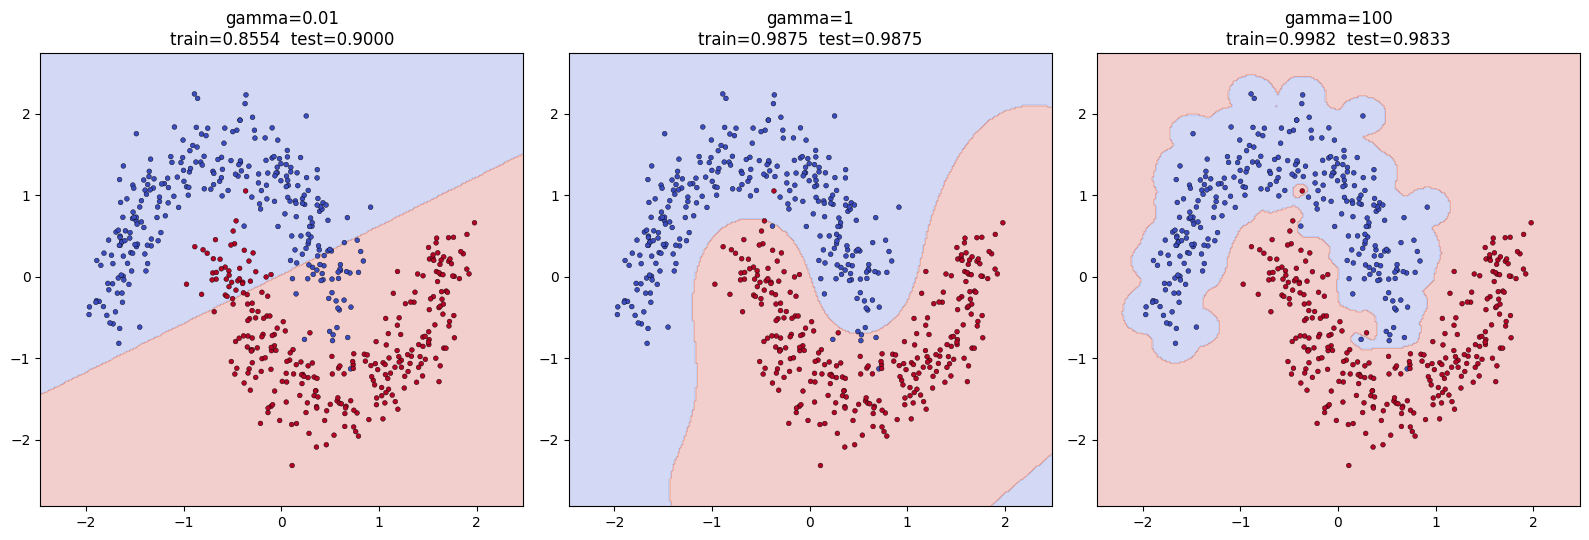

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, g in zip(axes, [0.01, 1, 100]):
    m = SVC(kernel="rbf", C=1.0, gamma=g)
    m.fit(X_tr_s, y_tr)
    graficar_frontera(ax, m, f"gamma={g}\ntrain={m.score(X_tr_s, y_tr):.4f}  test={m.score(X_te_s, y_te):.4f}")
plt.tight_layout()
plt.show()

**Lectura:** el barrido numérico confirma la teoría. Con $\gamma=0.01$ (muy pequeño), la exactitud es la más baja de todo el barrido (85.54% train, 90.00% test) y usa **240** vectores de soporte (43% del entrenamiento) — la frontera es tan suave que apenas mejora al kernel lineal, un caso de **subajuste**. En el extremo opuesto, $\gamma=100$ alcanza la exactitud de entrenamiento más alta de todas (**99.82%**) pero con la exactitud de *prueba* ligeramente por debajo del óptimo (98.33% vs. 98.75% en $\gamma=1$ y $\gamma=10$) y, sobre todo, usando **451** vectores de soporte —¡el 80.5% del entrenamiento!—, un síntoma claro de que el modelo está memorizando puntos individuales en lugar de aprender una forma general. El gráfico lo confirma visualmente: con $\gamma=100$ aparecen pequeñas "islas" de color alrededor de puntos aislados, burbujas de frontera que envuelven un solo punto en lugar de seguir la forma continua de la luna — la firma visual clásica del sobreajuste. El punto óptimo está en la zona intermedia ($\gamma=1$ o $\gamma=10$, ambos con 98.75% de exactitud de prueba), donde la frontera sigue la curvatura real de los datos sin perseguir cada punto individual.

---
## 6. El Kernel Polinomial: Fórmula y Comparación Rápida 🔺

El otro kernel no lineal común es el **polinomial**:

$$K(x, z) = (\gamma\, x^T z + r)^d$$

donde $d$ es el grado del polinomio (`degree`), $\gamma$ escala el producto punto, y $r$ (`coef0`) es un término independiente. A diferencia de RBF, que tiene un único hiperparámetro central ($\gamma$), el kernel polinomial depende fuertemente de la combinación de **tres** hiperparámetros ($\gamma$, $r$, $d$), lo que lo hace más sensible a una mala elección. Se prueba con los valores por defecto de scikit-learn (`gamma="scale"`, `coef0=0.0`) variando solo `degree`, sobre el mismo problema de las lunas.

In [7]:
for d in [2, 3, 4]:
    m = SVC(kernel="poly", degree=d, C=1.0)
    m.fit(X_tr_s, y_tr)
    print(f"grado={d}   train={m.score(X_tr_s, y_tr):.4f}   test={m.score(X_te_s, y_te):.4f}")

print(f"\nPara comparar, kernel RBF (gamma='scale'): train={svc_rbf.score(X_tr_s, y_tr):.4f}   test={svc_rbf.score(X_te_s, y_te):.4f}")

grado=2   train=0.5089   test=0.5083
grado=3   train=0.8786   test=0.9125
grado=4   train=0.5143   test=0.4875

Para comparar, kernel RBF (gamma='scale'): train=0.9839   test=0.9792


**Lectura:** el resultado es una advertencia útil sobre la fragilidad del kernel polinomial frente a la robustez de RBF. Con `degree=3`, el desempeño es razonable (87.86% train, 91.25% test) — mejor que el kernel lineal, aunque todavía por debajo de RBF. Pero con `degree=2` y `degree=4`, la exactitud **se desploma a apenas ~50%**, esencialmente equivalente a adivinar al azar en un problema balanceado de 2 clases. La causa no es un error de código: con `coef0=0`, el kernel polinomial de grado par pierde la capacidad de representar de forma efectiva ciertas combinaciones necesarias para este problema, un efecto conocido de la interacción entre `degree` y `coef0`. La lección práctica es clara: mientras que RBF fue razonablemente estable a través de dos órdenes de magnitud de `gamma` en la Sección 5 (nunca bajó de 85%), el kernel polinomial exige afinar **simultáneamente** `degree`, `gamma` y `coef0` para obtener resultados competitivos — por eso RBF suele ser la opción por defecto cuando no hay una razón específica para preferir un polinomio.

---
## 7. Regresión de Soporte Vectorial (SVR): El Tubo $\varepsilon$-insensible 🚇

Todo lo anterior fue clasificación. El mismo principio de kernels se extiende a **regresión** mediante **SVR** (*Support Vector Regression*), pero con una función de pérdida distinta a la de una regresión lineal clásica. En lugar de penalizar todo error de predicción, SVR define un **tubo $\varepsilon$-insensible** alrededor de la función de predicción: cualquier punto cuyo error absoluto sea **menor** que $\varepsilon$ **no recibe ninguna penalización**, sin importar qué tan cerca o lejos esté del centro del tubo, mientras se mantenga dentro de él. Solo los puntos que caen **fuera** del tubo aportan costo a la función objetivo — y son, precisamente, esos puntos los que se convierten en los vectores de soporte del modelo de regresión.

$$L_\varepsilon(y, f(x)) = \max(0, \, |y - f(x)| - \varepsilon)$$

Esta sección compara SVR con kernel RBF contra una regresión lineal simple sobre `rendimiento_industrial_no_lineal.csv`, cuyo nombre ya sugiere una relación no lineal entre las variables de proceso y la eficiencia resultante.

In [8]:
df_ind = pd.read_csv(load_dataset("rendimiento_industrial_no_lineal.csv"))

print("Forma del dataset:", df_ind.shape)
print("\nValores nulos por columna:")
print(df_ind.isnull().sum())
print("\nEstadisticas descriptivas:")
print(df_ind.describe())

Forma del dataset: (2000, 6)

Valores nulos por columna:
temperatura_c             0
presion_bar               0
flujo_l_min               0
rpm_motor                 0
concentracion_reactivo    0
eficiencia_proceso        0
dtype: int64

Estadisticas descriptivas:
       temperatura_c  presion_bar  flujo_l_min    rpm_motor  \
count    2000.000000  2000.000000  2000.000000  2000.000000   
mean      115.357500     6.772855    46.335335  2404.033250   
std        37.433544     2.979260    21.727292   693.725423   
min        50.030000     1.500000    10.000000  1200.800000   
25%        82.887500     4.280000    26.747500  1810.950000   
50%       115.775000     6.735000    46.455000  2402.250000   
75%       147.245000     9.260000    65.120000  3003.750000   
max       179.990000    11.980000    84.980000  3598.800000   

       concentracion_reactivo  eficiencia_proceso  
count             2000.000000         2000.000000  
mean                 0.500422           49.960490  
std       

**Lectura:** 2000 filas sin valores nulos, con la variable objetivo `eficiencia_proceso` en un rango de 20.0 a 98.5 (media 49.96, desviación estándar 20.92). Las variables predictoras (`temperatura_c`, `presion_bar`, `flujo_l_min`, `rpm_motor`, `concentracion_reactivo`) están en escalas muy distintas entre sí, así que —como en el Cuaderno 00— es indispensable estandarizarlas antes de entrenar cualquier modelo basado en distancias.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

Xr = df_ind.drop(columns=["eficiencia_proceso"]).values
yr = df_ind["eficiencia_proceso"].values

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.3, random_state=42)

scaler_r = StandardScaler().fit(Xr_tr)
Xr_tr_s = scaler_r.transform(Xr_tr)
Xr_te_s = scaler_r.transform(Xr_te)

# Regresion lineal (referencia)
modelo_lineal = LinearRegression()
modelo_lineal.fit(Xr_tr_s, yr_tr)
pred_lineal = modelo_lineal.predict(Xr_te_s)
r2_lineal = r2_score(yr_te, pred_lineal)
rmse_lineal = mean_squared_error(yr_te, pred_lineal) ** 0.5

# SVR con kernel RBF
modelo_svr = SVR(kernel="rbf", C=10, gamma="scale", epsilon=0.5)
modelo_svr.fit(Xr_tr_s, yr_tr)
pred_svr = modelo_svr.predict(Xr_te_s)
r2_svr = r2_score(yr_te, pred_svr)
rmse_svr = mean_squared_error(yr_te, pred_svr) ** 0.5

print(f"Regresion lineal      -> R2: {r2_lineal:.4f}   RMSE: {rmse_lineal:.4f}")
print(f"SVR (kernel RBF)      -> R2: {r2_svr:.4f}   RMSE: {rmse_svr:.4f}")
print(f"\nVectores de soporte del SVR: {modelo_svr.support_vectors_.shape[0]} de {len(yr_tr)} "
      f"({100*modelo_svr.support_vectors_.shape[0]/len(yr_tr):.1f}% del entrenamiento)")

Regresion lineal      -> R2: 0.8429   RMSE: 8.3689
SVR (kernel RBF)      -> R2: 0.9836   RMSE: 2.7039

Vectores de soporte del SVR: 1176 de 1400 (84.0% del entrenamiento)


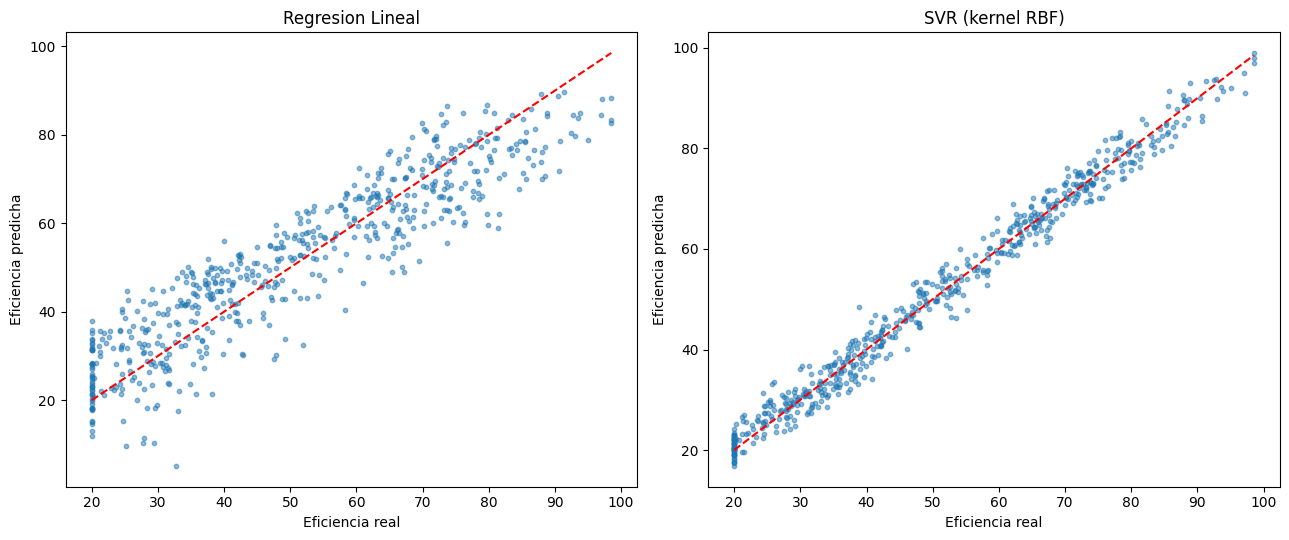

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, pred, titulo in zip(axes, [pred_lineal, pred_svr], ["Regresion Lineal", "SVR (kernel RBF)"]):
    ax.scatter(yr_te, pred, s=10, alpha=0.5)
    ax.plot([yr_te.min(), yr_te.max()], [yr_te.min(), yr_te.max()], "r--", linewidth=1.5)
    ax.set_xlabel("Eficiencia real")
    ax.set_ylabel("Eficiencia predicha")
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

**Lectura:** la diferencia es honesta y dramática. La regresión lineal alcanza $R^2 = 0.8429$ (RMSE = 8.37) — ya es un ajuste razonable, lo que indica que existe una componente lineal apreciable en la relación entre las variables de proceso y la eficiencia. Pero SVR con kernel RBF llega a $R^2 = 0.9836$ (RMSE = 2.70): explica **98.4%** de la varianza frente al 84.3% del modelo lineal, y reduce el error típico de predicción a menos de un tercio (de 8.37 a 2.70 puntos de eficiencia). El gráfico de dispersión de valores predichos contra reales lo confirma visualmente: los puntos de la regresión lineal forman una nube ancha y sistemáticamente desviada de la diagonal (especialmente en los extremos del rango), mientras que los del SVR se ciñen de forma mucho más ajustada a la línea de predicción perfecta a lo largo de **todo** el rango de eficiencia. Esta es exactamente la componente **no lineal** que el nombre del dataset (`rendimiento_industrial_no_lineal`) sugería, y que un modelo lineal, por diseño, no puede capturar sin importar cuán bien se ajusten sus coeficientes. El SVR usó **1176** de los 1400 puntos de entrenamiento (84.0%) como vectores de soporte — es decir, con $\varepsilon=0.5$, la mayoría de los puntos caen fuera del tubo de tolerancia, lo cual es razonable dado que el error residual típico del propio modelo (RMSE $\approx$ 2.70) es varias veces mayor que $\varepsilon$.

---
## 8. Ejercicio Práctico Guiado: El Efecto de $\varepsilon$ en la Esparsidad del SVR ✍️

**Contexto:** la Sección 7 fijó $\varepsilon=0.5$ sin justificarlo más allá de "es razonable". Este ejercicio explora directamente qué ocurre al variar $\varepsilon$: ¿cómo cambian el desempeño ($R^2$) y el número de vectores de soporte del modelo?

**Tu misión:**
1. Para cada valor de $\varepsilon$ en `[0.1, 0.5, 1, 2, 5]`, entrena un `SVR(kernel="rbf", C=10, gamma="scale", epsilon=eps)` sobre `Xr_tr_s`, `yr_tr` (los mismos datos escalados de la Sección 7).
2. Para cada modelo, calcula $R^2$ sobre el conjunto de prueba y cuenta cuántos vectores de soporte usa (y qué porcentaje representa sobre el total de entrenamiento).
3. Imprime una tabla con las 5 filas (una por valor de $\varepsilon$), con columnas de $R^2$, RMSE, número de vectores de soporte y porcentaje.
4. Identifica: ¿en qué valor de $\varepsilon$ el $R^2$ es máximo? ¿Qué le ocurre al número de vectores de soporte a medida que $\varepsilon$ crece?
5. Interpreta en un comentario: ¿por qué un tubo más ancho ($\varepsilon$ mayor) reduce el número de vectores de soporte, y hasta qué punto se puede ensanchar el tubo antes de perder desempeño?

In [11]:
### TU CODIGO AQUI ###

# 1 y 2. Entrena un SVR para cada epsilon y registra R2, RMSE y vectores de soporte
epsilons = [0.1, 0.5, 1, 2, 5]
resultados_epsilon = []  # lista de dicts o tuplas con los resultados de cada epsilon

# 3. Construye e imprime una tabla (ej. con pandas.DataFrame) con los resultados

# 4. Identifica el epsilon con R2 maximo y describe la tendencia del numero de vectores de soporte

# 5. Escribe tu interpretacion como comentario aqui

<details>
<summary>💡 Haz clic aquí para ver la solución guiada...</summary>

```python
epsilons = [0.1, 0.5, 1, 2, 5]
resultados_epsilon = []

for eps in epsilons:
    m = SVR(kernel="rbf", C=10, gamma="scale", epsilon=eps)
    m.fit(Xr_tr_s, yr_tr)
    pred = m.predict(Xr_te_s)
    r2 = r2_score(yr_te, pred)
    rmse = mean_squared_error(yr_te, pred) ** 0.5
    n_sv = m.support_vectors_.shape[0]
    resultados_epsilon.append({
        "epsilon": eps, "R2": round(r2, 4), "RMSE": round(rmse, 4),
        "n_vectores_soporte": n_sv, "pct_entrenamiento": round(100 * n_sv / len(yr_tr), 1)
    })

tabla_epsilon = pd.DataFrame(resultados_epsilon)
print(tabla_epsilon.to_string(index=False))

mejor = tabla_epsilon.loc[tabla_epsilon["R2"].idxmax()]
print(f"\nMejor R2 en epsilon={mejor['epsilon']}: R2={mejor['R2']}")
```

Resultado real:

| epsilon | R2 | RMSE | n_vectores_soporte | pct_entrenamiento |
|---|---|---|---|---|
| 0.1 | 0.9833 | 2.7294 | 1348 | 96.3% |
| 0.5 | 0.9836 | 2.7039 | 1176 | 84.0% |
| 1.0 | 0.9838 | 2.6860 | 972 | 69.4% |
| 2.0 | 0.9834 | 2.7232 | 608 | 43.4% |
| 5.0 | 0.9756 | 3.2956 | 183 | 13.1% |

**Interpretación:** el $R^2$ máximo (**0.9838**) ocurre en $\varepsilon=1.0$, apenas por encima del resto — entre $\varepsilon=0.1$ y $\varepsilon=2.0$ el desempeño es prácticamente indistinguible (todos entre 0.9833 y 0.9838). Lo que sí cambia de forma dramática es el número de vectores de soporte: cae de **1348** (96.3% del entrenamiento) con $\varepsilon=0.1$ a solo **183** (13.1%) con $\varepsilon=5.0$ — una reducción de más de 7 veces. Esto confirma directamente la definición del tubo $\varepsilon$-insensible: cuanto más ancho el tubo, más puntos de entrenamiento caen **dentro** de él y dejan de aportar penalización (ni de convertirse en vectores de soporte), así que el modelo se vuelve más "esparso" (más liviano, más rápido de evaluar) sin sacrificar apenas precisión. El límite se alcanza en $\varepsilon=5.0$: ahí el tubo ya es tan ancho —recuérdese que el RMSE del propio modelo ronda 2.7 a 3.3— que empieza a ignorar señal real, y el $R^2$ cae de forma visible (0.9756, el único valor claramente por debajo del resto) mientras el RMSE sube a 3.30. La lección práctica es que $\varepsilon$ no solo controla la tolerancia al ruido: es también una palanca directa para controlar la **esparsidad** (y por lo tanto la velocidad de predicción) de un modelo SVR, con una zona amplia donde se puede ensanchar el tubo casi sin costo en precisión antes de cruzar el punto donde el desempeño empieza a resentirse.

</details>

---
## 9. Resumen Ejecutivo 🎓

Este cuaderno extendió las Máquinas de Soporte Vectorial más allá de las fronteras rectas del Cuaderno 00, mediante el **truco del kernel**, y las llevó también al terreno de la regresión. Los hallazgos centrales, todos medidos sobre datos reales de este módulo:

- **El kernel lineal no basta cuando la geometría es curva:** sobre `geometria_lunas.csv`, un SVM lineal alcanzó 90.00% de exactitud de prueba — no catastrófico, pero con errores sistemáticamente concentrados en las puntas curvas de cada medialuna, precisamente donde una línea recta no puede seguir la forma de los datos.
- **El truco del kernel** permite operar, de forma indirecta pero exacta (Teorema de Mercer), como si los datos hubiesen sido proyectados a un espacio de mayor dimensión donde sí son separables — sin pagar el costo computacional de construir ese espacio explícitamente.
- **El kernel RBF cerró casi toda la brecha:** 97.92% de exactitud de prueba (frente al 90.00% lineal), con una frontera que se curva con naturalidad alrededor de cada luna, usando solo 84 vectores de soporte (15% del entrenamiento) concentrados en la zona de entrelazamiento.
- **El barrido de `gamma`** mostró ambos extremos con datos reales: $\gamma=0.01$ subajusta (85.54% de exactitud, casi tan pobre como el kernel lineal) y $\gamma=100$ sobreajusta visiblemente (aparecen "islas" de frontera alrededor de puntos individuales, y el 80.5% del entrenamiento termina siendo vector de soporte).
- **El kernel polinomial es más frágil que RBF:** con los hiperparámetros por defecto, `degree=3` funcionó razonablemente (91.25%), pero `degree=2` y `degree=4` colapsaron a ~50% (equivalente al azar) por la interacción entre `degree` y `coef0`.
- **SVR con tubo $\varepsilon$-insensible superó ampliamente a una regresión lineal** sobre `rendimiento_industrial_no_lineal.csv`: $R^2=0.9836$ frente a $0.8429$, con un RMSE tres veces menor (2.70 vs. 8.37) — evidencia directa de la componente no lineal del proceso industrial.
- **El ejercicio mostró que $\varepsilon$ controla la esparsidad del modelo** casi independientemente de su precisión: ensanchar el tubo de $\varepsilon=0.1$ a $\varepsilon=2.0$ redujo los vectores de soporte de 96.3% a 43.4% del entrenamiento con una pérdida de $R^2$ inferior a 0.001, antes de que el desempeño empezara a resentirse en $\varepsilon=5.0$.

**Hacia adelante en el Módulo 06:** los dos primeros cuadernos agotaron la familia de las Máquinas de Soporte Vectorial — margen máximo, margen blando, y el truco del kernel para fronteras no lineales. El Cuaderno **02 — Redes Neuronales** — cambia por completo de paradigma: en lugar de elegir un kernel a mano para transformar el espacio de entrada, una red neuronal **aprende** sus propias transformaciones no lineales a partir de los datos, capa por capa. El Cuaderno **03 — Retropropagación** — abre la caja negra de ese aprendizaje, mostrando el algoritmo que ajusta los pesos de la red. El Cuaderno **04 — Comparativa** — cierra el módulo confrontando ambas familias (SVM y redes neuronales) con evidencia empírica sobre los mismos datos, para responder cuándo conviene cada una.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | SVM y Redes Neuronales</i>
  </p>
</div>